# Customer Churn Prediction — Exploratory Data Analysis

## Objective

Understand the customer churn dataset, identify data quality issues,
analyze the target variable, explore feature relationships, and determine
the preprocessing requirements for model development.

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [3]:
data_path = Path("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(data_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 7043
Number of columns: 21


### 📐 Dataset Shape Summary

- **Number of Rows (Observations):** 7043  
  
- **Number of Columns (Features):** 21  

✅ This means the dataset contains **7043 customer entries** with **21 different features** available for analysis.  



In [6]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

### 📑 Dataset Feature Dictionary

This dataset contains **7043 rows** and **21 columns**. Below is a description of each feature:

- **customerID** → Unique identifier for each customer.  
- **gender** → Customer’s gender (Male/Female).  
- **SeniorCitizen** → Indicates if the customer is a senior (1 = Yes, 0 = No).  
- **Partner** → Whether the customer has a partner (Yes/No).  
- **Dependents** → Whether the customer has dependents (Yes/No).  
- **tenure** → Number of months the customer has stayed with the company.  
- **PhoneService** → Whether the customer has a phone service (Yes/No).  
- **MultipleLines** → Whether the customer has multiple phone lines (Yes/No/No phone service).  
- **InternetService** → Type of internet service (DSL/Fiber optic/No).  
- **OnlineSecurity** → Whether the customer has online security add‑on (Yes/No/No internet service).  
- **OnlineBackup** → Whether the customer has online backup add‑on (Yes/No/No internet service).  
- **DeviceProtection** → Whether the customer has device protection add‑on (Yes/No/No internet service).  
- **TechSupport** → Whether the customer has tech support add‑on (Yes/No/No internet service).  
- **StreamingTV** → Whether the customer has streaming TV service (Yes/No/No internet service).  
- **StreamingMovies** → Whether the customer has streaming movies service (Yes/No/No internet service).  
- **Contract** → Type of contract (Month‑to‑month/One year/Two year).  
- **PaperlessBilling** → Whether the customer uses paperless billing (Yes/No).  
- **PaymentMethod** → Customer’s payment method (Electronic check, Mailed check, Bank transfer, Credit card).  
- **MonthlyCharges** → The amount charged to the customer monthly.  
- **TotalCharges** → The total amount charged to the customer over tenure.  
- **Churn** → Target variable: whether the customer left the company (Yes/No).


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 🧾 Dataset Info Summary

- **Total Entries (Rows):** 7043  
- **Total Features (Columns):** 21  

#### 🔍 Column Details
- **customerID** → Unique customer identifier *(string)*  
- **gender** → Gender of the customer *(string)*  
- **SeniorCitizen** → Senior flag (0 = No, 1 = Yes) *(int)*  
- **Partner** → Whether the customer has a partner *(string)*  
- **Dependents** → Whether the customer has dependents *(string)*  
- **tenure** → Number of months with the company *(int)*  
- **PhoneService** → Phone service availability *(string)*  
- **MultipleLines** → Multiple phone lines status *(string)*  
- **InternetService** → Type of internet service *(string)*  
- **OnlineSecurity** → Online security add‑on *(string)*  
- **OnlineBackup** → Online backup add‑on *(string)*  
- **DeviceProtection** → Device protection add‑on *(string)*  
- **TechSupport** → Tech support add‑on *(string)*  
- **StreamingTV** → Streaming TV service *(string)*  
- **StreamingMovies** → Streaming movies service *(string)*  
- **Contract** → Contract type *(string)*  
- **PaperlessBilling** → Paperless billing flag *(string)*  
- **PaymentMethod** → Payment method *(string)*  
- **MonthlyCharges** → Monthly charges *(float)*  
- **TotalCharges** → Total charges *(string — needs conversion to numeric)*  
- **Churn** → Target variable: customer churn status *(string)*  

#### ⚙️ Data Types Overview
- **Numerical:** `SeniorCitizen`, `tenure`, `MonthlyCharges`  
- **Categorical (string):** 18 columns including demographics, services, and churn label  
- **Note:** `TotalCharges` is stored as string but should be converted to numeric for analysis.



In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### 📉 Churn Distribution

- **No (Did not churn):** 5174 customers  
- **Yes (Churned):** 1869 customers  

#### 🔎 Insights
- The dataset is **imbalanced**:  
  - ~73.5% of customers did **not churn**  
  - ~26.5% of customers **churned**  

✅ This imbalance is important to consider during model building. Techniques such as **resampling (SMOTE, undersampling, oversampling)**, **class weighting**, or **evaluation with metrics beyond accuracy** (e.g., precision, recall, F1‑score, ROC‑AUC) will help ensure fair performance across both classes.


C:\Users\ANEES\AppData\Local\Temp\ipykernel_18680\341532981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Churn", palette=["#4CAF50", "#F44336"], edgecolor="black")


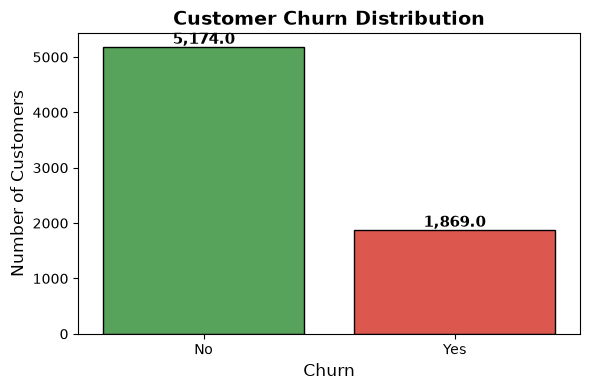

In [13]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="Churn", palette=["#4CAF50", "#F44336"], edgecolor="black")

plt.title("Customer Churn Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Churn", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Add value labels on each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,}',  # formatted with commas
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()


### 📊 Customer Churn Distribution with Value Labels

The bar chart below shows the distribution of churned vs. non‑churned customers:

- **No (Did not churn):** 5174 customers  
- **Yes (Churned):** 1869 customers  

#### 🔎 Key Points
- Value counts are displayed directly on top of each bar for clarity.  
- This makes the chart more **informative and presentation‑ready**, as both the visual proportions and exact numbers are visible.  
- The imbalance remains clear:
  - ~73.5% of customers did **not churn**
  - ~26.5% of customers **churned**

In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 🧹 Missing Values Check

The dataset was inspected for **null/missing values** across all 21 features.

#### ✅ Results
- **No missing values detected** in any column.  
- Each feature has **7043 non‑null entries**, matching the total number of rows.

#### 🔎 Implications
- No immediate need for imputation or removal of rows/columns.  
- This ensures a **clean dataset** ready for preprocessing and modeling.  
- Focus can shift to **data type conversions** (e.g., `TotalCharges` from string → numeric) and **encoding categorical variables**.

✅ A complete dataset with no missing values provides a strong foundation for reliable churn analysis.


In [19]:
df["TotalCharges"].dtype
df["TotalCharges"].value_counts().tail()
(df["TotalCharges"].astype(str).str.strip() == "").sum()
pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
).isna().sum()

np.int64(11)

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

C:\Users\ANEES\AppData\Local\Temp\ipykernel_18680\1797605437.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

In [24]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection
<StringArray>
['No', 'Yes', 'No internet service']


In [25]:
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

In [26]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


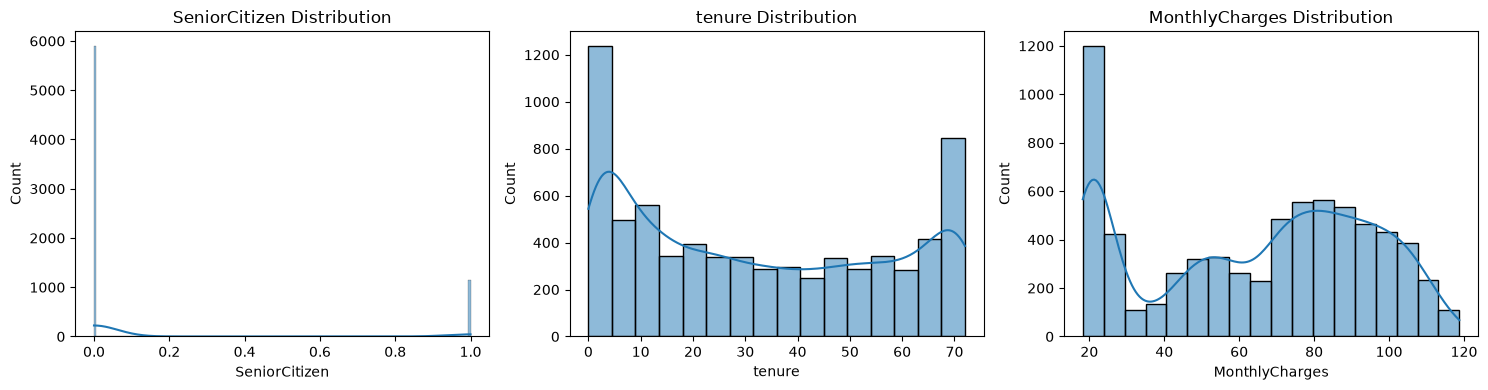

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, column in zip(axes, numeric_columns):
    sns.histplot(data=df, x=column, kde=True, ax=ax)
    ax.set_title(f"{column} Distribution")

plt.tight_layout()
plt.show()

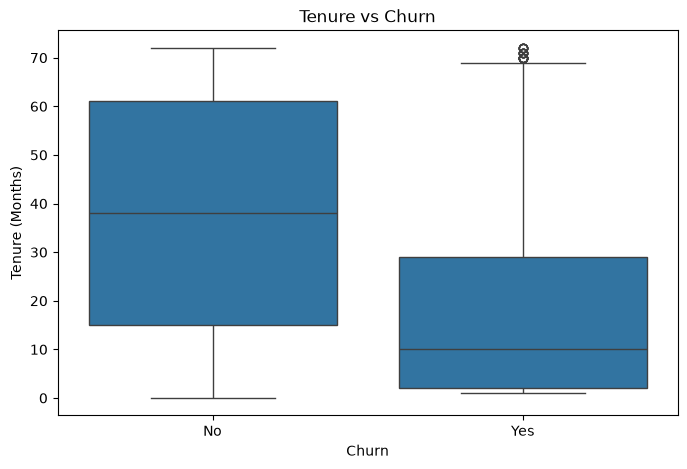

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

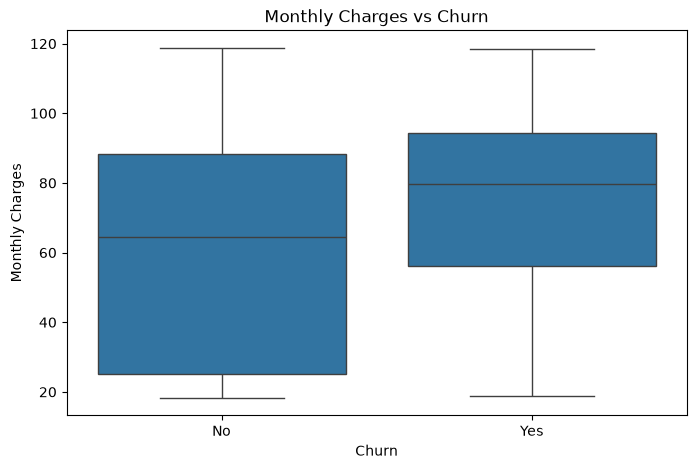

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [30]:
df.groupby("Churn")[["tenure", "MonthlyCharges"]].mean()

,tenure,MonthlyCharges
Churn,,
No,37.569965,61.265124
Yes,17.979133,74.441332


In [31]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


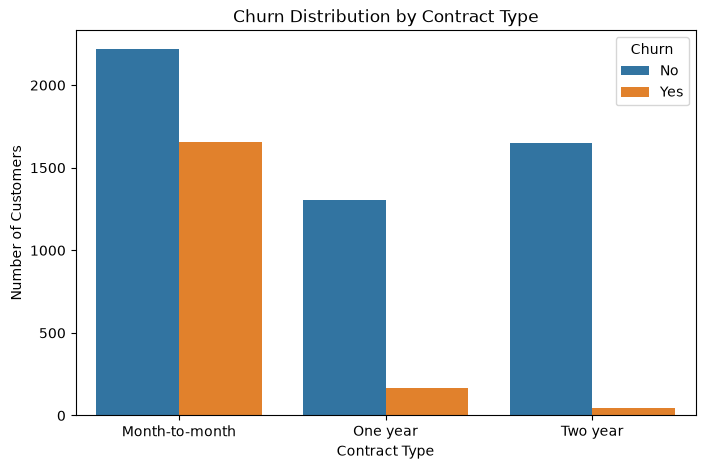

In [32]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### 📑 Churn Distribution by Contract Type

The bar chart below compares churn across different contract types:

- **Month-to-month** → Highest churn rate, with a large proportion of customers leaving.  
- **One year** → Moderate churn, showing better retention compared to month-to-month.  
- **Two year** → Lowest churn rate, indicating strong customer retention.

#### 🔎 Insights
- Customers on **short-term (month-to-month) contracts** are more likely to churn.  
- Longer contracts (**one year, two year**) are associated with **higher loyalty and reduced churn**.  
- This suggests that **contract duration is a key driver of customer retention**.

✅ Businesses can use this insight to encourage customers to switch from month-to-month to longer-term contracts, potentially reducing churn.


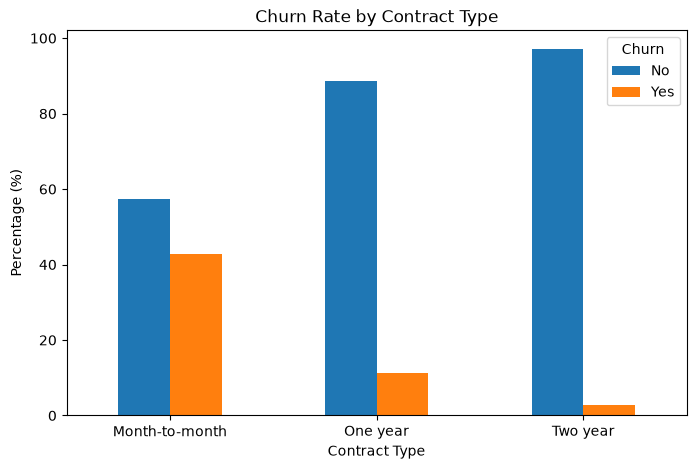

In [33]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [34]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


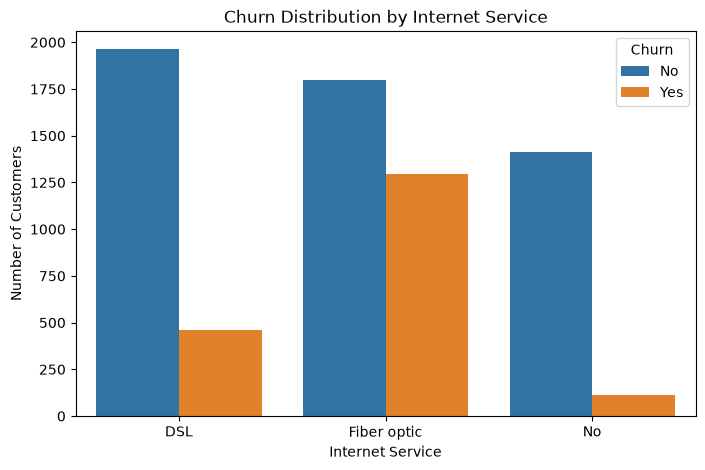

In [35]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Churn Distribution by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### 🌐 Churn Distribution by Internet Service

The bar chart compares churn across different internet service categories:

- **DSL** → Majority of customers did not churn, though churn is still present.  
- **Fiber optic** → Higher churn rate compared to DSL, showing weaker retention.  
- **No internet service** → Very low churn, since these customers are less engaged with services.

#### 🔎 Insights
- Customers with **Fiber optic service** are more likely to churn than DSL customers.  
- Customers without internet service show the **lowest churn**, but they also represent a smaller, less engaged group.  
- Internet service type is a **significant factor influencing churn behavior**.

✅ This suggests that improving customer experience for **Fiber optic users** could help reduce churn, while DSL customers show relatively stronger loyalty.


In [36]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


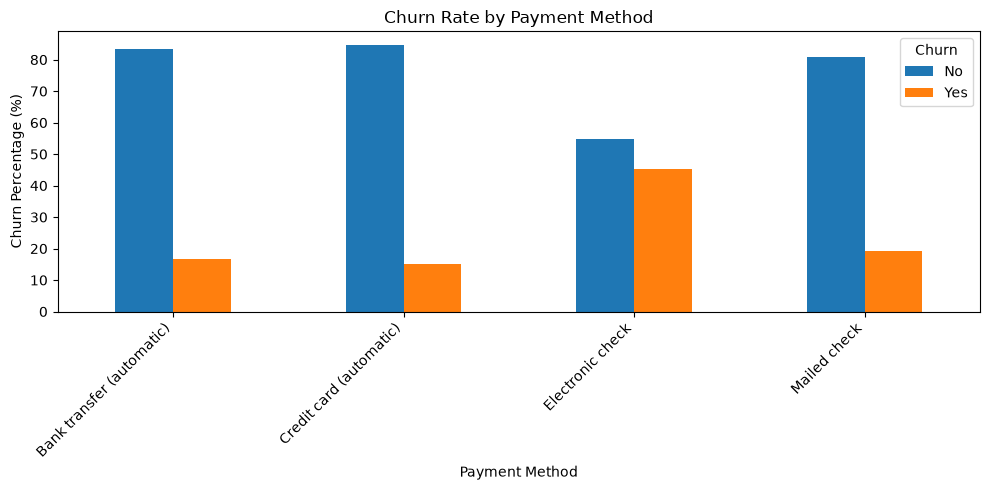

In [37]:
payment_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Percentage (%)")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

### 💳 Churn Rate by Payment Method

The chart compares churn percentages across different payment methods:

- **Bank transfer (automatic)** → Lowest churn rate, strong customer retention.  
- **Credit card (automatic)** → Similarly low churn, showing stable loyalty.  
- **Electronic check** → Highest churn rate, indicating weaker retention.  
- **Mailed check** → Moderate churn, better than electronic check but not as strong as automatic methods.

#### 🔎 Insights
- Customers using **automatic payment methods** (bank transfer, credit card) are **less likely to churn**.  
- Customers paying via **electronic check** are at the **highest risk of churn**.  
- Payment method is a **behavioral indicator of loyalty** — automatic payments may reduce friction and increase retention.

✅ Businesses can encourage customers to adopt **automatic payment options** to reduce churn risk.


In [40]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 60, np.inf],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-60 months",
        "60+ months"
    ]
)

In [41]:
tenure_churn = pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
tenure_group,,
0-12 months,52.321839,47.678161
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-60 months,85.576923,14.423077
60+ months,93.390192,6.609808


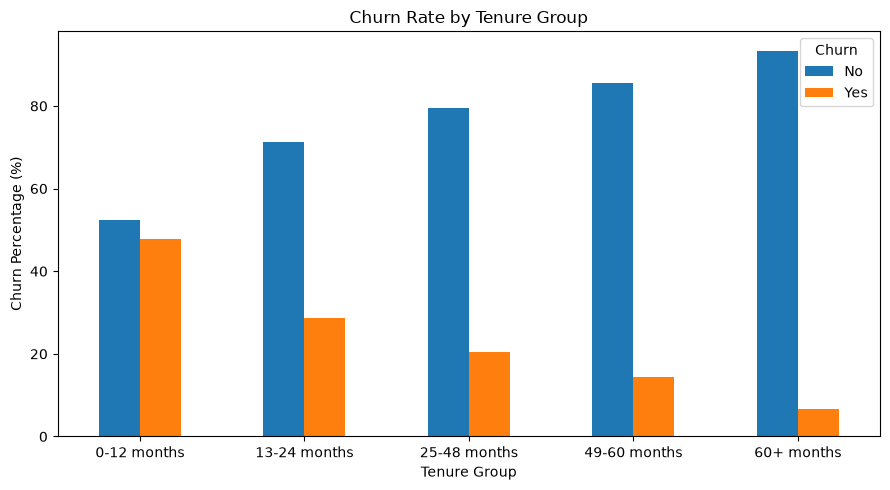

In [42]:
tenure_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Percentage (%)")

plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

### ⏳ Churn Rate by Tenure Group

The chart compares churn percentages across different tenure ranges:

- **0–12 months** → Highest churn rate, showing that new customers are most likely to leave.  
- **13–24 months** → Churn decreases compared to the first year, but retention is still moderate.  
- **25–48 months** → Further decline in churn, stronger retention.  
- **49–60 months** → Churn continues to drop, loyalty increases.  
- **60+ months** → Lowest churn rate, customers with long tenure are highly loyal.

#### 🔎 Insights
- **Customer tenure is strongly linked to churn behavior.**  
- The longer a customer stays, the less likely they are to churn.  
- Early churn (within the first year) is the biggest challenge for retention strategies.  

✅ Businesses should focus on **onboarding and engagement programs** during the first year to reduce churn risk and build long‑term loyalty.



In [43]:
df.drop(columns=["tenure_group"], inplace=True)

In [44]:
binary_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

In [45]:
for column in binary_columns:
    churn_rate = pd.crosstab(
        df[column],
        df["Churn"],
        normalize="index"
    ) * 100
    
    print(f"\n{'=' * 50}")
    print(f"{column}")
    print(f"{'=' * 50}")
    print(churn_rate)


gender
Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338

Partner
Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903

Dependents
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237

PhoneService
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637

PaperlessBilling
Churn                    No        Yes
PaperlessBilling                      
No                83.669916  16.330084
Yes               66.434908  33.565092


In [46]:
service_columns = [
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [47]:
for column in service_columns:
    churn_rate = pd.crosstab(
        df[column],
        df["Churn"],
        normalize="index"
    ) * 100
    
    print(f"\n{'=' * 50}")
    print(f"{column}")
    print(f"{'=' * 50}")
    print(churn_rate)


MultipleLines
Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896

OnlineSecurity
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194

OnlineBackup
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494

DeviceProtection
Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064

TechSupport
Churn                       No        Yes
TechSupport                              
No             

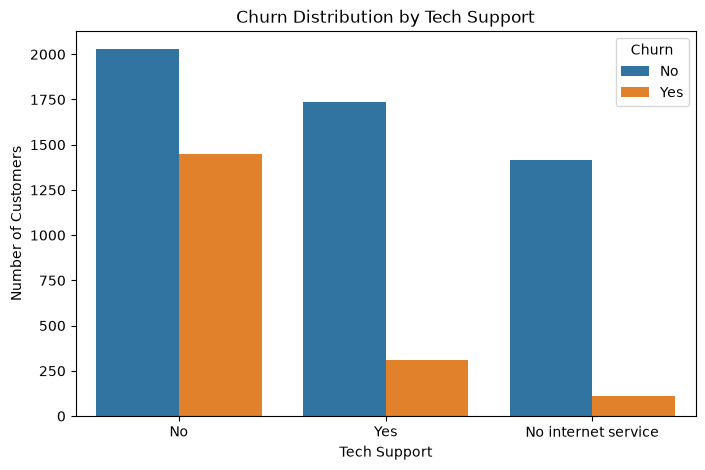

In [48]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)

plt.title("Churn Distribution by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.show()

In [49]:
tech_support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

tech_support_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [50]:
def churn_rate_by_category(data, column, target="Churn"):
    return (
        pd.crosstab(
            data[column],
            data[target],
            normalize="index"
        ) * 100
    )

In [51]:
correlation = df[numeric_columns].corr()

correlation

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


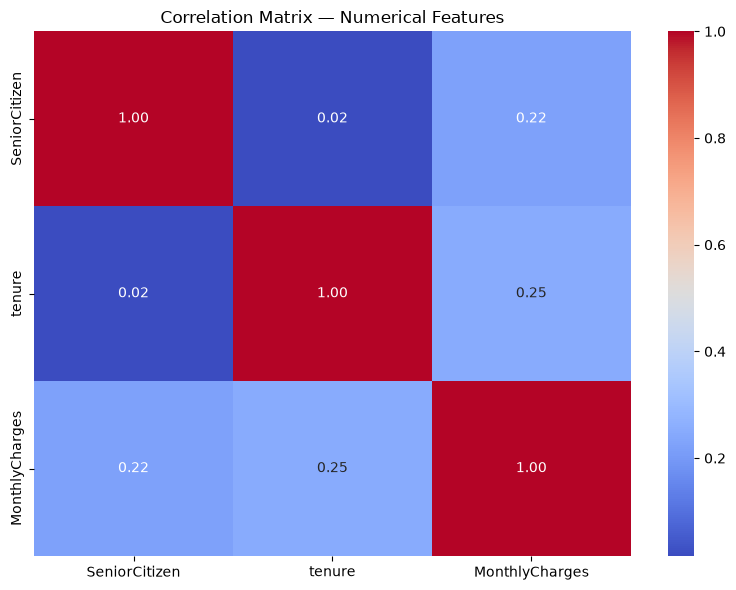

In [52]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix — Numerical Features")

plt.tight_layout()
plt.show()

In [53]:
churn_rate_by_category(df, "Contract")

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [54]:
churn_rate_by_category(df, "InternetService")

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [55]:
df.groupby("Churn")[["tenure", "MonthlyCharges"]].mean()

,tenure,MonthlyCharges
Churn,,
No,37.569965,61.265124
Yes,17.979133,74.441332


In [56]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [57]:
total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

invalid_total_charges = total_charges_numeric.isna()

print("Invalid TotalCharges:", invalid_total_charges.sum())

Invalid TotalCharges: 11


In [58]:
df.loc[
    invalid_total_charges,
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [59]:
numerical_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges"
]

In [60]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


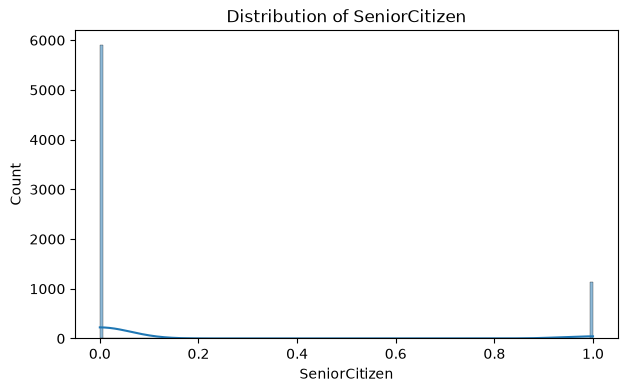

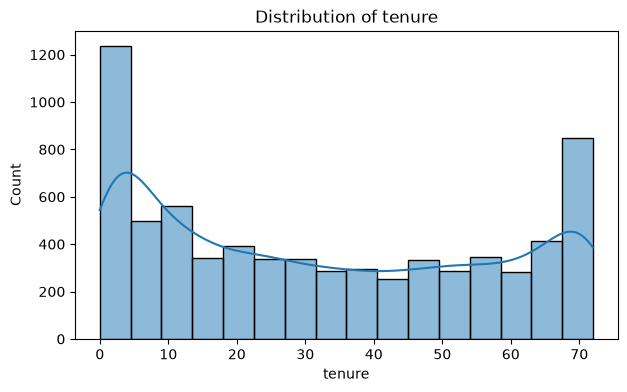

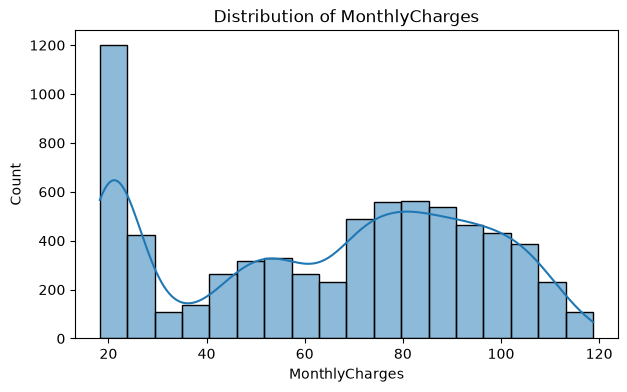

In [61]:
for column in numerical_columns:
    plt.figure(figsize=(7, 4))
    
    sns.histplot(
        data=df,
        x=column,
        kde=True
    )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    
    plt.show()

In [62]:
churn_rate_by_category(df, "SeniorCitizen")

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


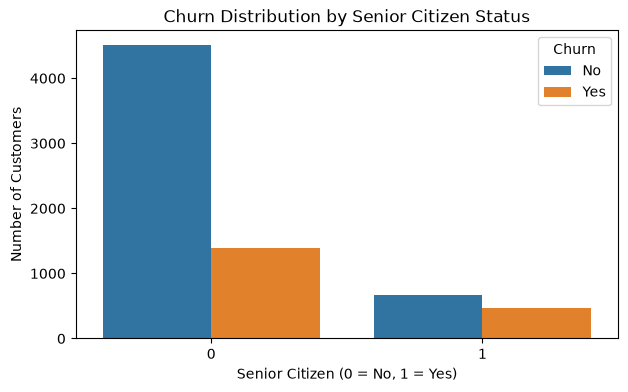

In [63]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Churn Distribution by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [64]:
feature_inventory = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.astype(str),
    "unique_values": df.nunique().values,
    "missing_values": df.isnull().sum().values
})

feature_inventory

,feature,dtype,unique_values,missing_values
customerID,customerID,str,7043,0
gender,gender,str,2,0
SeniorCitizen,SeniorCitizen,int64,2,0
Partner,Partner,str,2,0
Dependents,Dependents,str,2,0
tenure,tenure,int64,73,0
PhoneService,PhoneService,str,2,0
MultipleLines,MultipleLines,str,3,0
InternetService,InternetService,str,3,0
OnlineSecurity,OnlineSecurity,str,3,0


In [65]:
feature_inventory["numeric_conversion_missing"] = np.nan

In [66]:
feature_inventory.loc[
    feature_inventory["feature"] == "TotalCharges",
    "numeric_conversion_missing"
] = total_charges_numeric.isna().sum()

In [67]:
feature_inventory

,feature,dtype,unique_values,missing_values,numeric_conversion_missing
customerID,customerID,str,7043,0,NaN
gender,gender,str,2,0,NaN
SeniorCitizen,SeniorCitizen,int64,2,0,NaN
Partner,Partner,str,2,0,NaN
Dependents,Dependents,str,2,0,NaN
tenure,tenure,int64,73,0,NaN
PhoneService,PhoneService,str,2,0,NaN
MultipleLines,MultipleLines,str,3,0,NaN
InternetService,InternetService,str,3,0,NaN
OnlineSecurity,OnlineSecurity,str,3,0,NaN


In [68]:
categorical_features = [
    column
    for column in df.select_dtypes(include="object").columns
    if column not in ["customerID", "TotalCharges", "Churn"]
]

C:\Users\ANEES\AppData\Local\Temp\ipykernel_18680\3558130807.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include="object").columns


In [69]:
churn_summary = []

for column in categorical_features:
    rates = pd.crosstab(
        df[column],
        df["Churn"],
        normalize="index"
    ) * 100
    
    for category in rates.index:
        churn_summary.append({
            "Feature": column,
            "Category": category,
            "Churn_Rate": rates.loc[category, "Yes"]
        })

churn_summary = pd.DataFrame(churn_summary)

churn_summary.sort_values(
    "Churn_Rate",
    ascending=False
).head(20)

,Feature,Category,Churn_Rate
39,PaymentMethod,Electronic check,45.285412
32,Contract,Month-to-month,42.709677
12,InternetService,Fiber optic,41.892765
14,OnlineSecurity,No,41.766724
23,TechSupport,No,41.635474
17,OnlineBackup,No,39.928756
20,DeviceProtection,No,39.127625
29,StreamingMovies,No,33.680431
36,PaperlessBilling,Yes,33.565092
26,StreamingTV,No,33.523132


## EDA Conclusions

### Key Findings

1. The dataset contains customer-level information with `Churn` as the binary target.
2. The target is imbalanced, with non-churned customers representing the majority class.
3. `customerID` is an identifier and will not be used as a predictive feature.
4. `TotalCharges` is stored as text and contains values that require numeric conversion.
5. Contract type shows a strong observed relationship with churn.
6. Month-to-month customers have substantially higher observed churn than customers with one- or two-year contracts.
7. Churned customers have considerably lower average tenure.
8. Churned customers have higher average monthly charges.
9. Several service-related columns contain meaningful categories such as `No internet service` and `No phone service`; these should not automatically be treated as missing values.
10. Categorical features will require encoding before model training.
11. Numerical preprocessing will be handled through a reproducible transformation pipeline rather than manually modifying the raw dataset.
12. Further model evaluation will use metrics appropriate for the imbalanced classification problem, including precision, recall, F1-score and ROC-AUC.